# META-SiM Analysis

This notebook uses the `metasim` and `openfret` libraries to visualize processed single-molecule data.

In [47]:
# Install dependencies if not already present
# %pip install -q metasim openfret

In [48]:
import os
import json
import zipfile
import numpy as np
import openfret
import metasim
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1. Load Processed Data

We load the META-SiM processed `.json.zip` files which contain the latent embeddings for each trace.

In [49]:
data_dir = "./processed_data"

all_embeddings = []
all_labels = []
all_traces = []  # Store raw traces here

# Iterate over all zip files in the directory
file_list = [f for f in os.listdir(data_dir) if f.endswith('.json.zip')]
file_list.sort()

print(f"Found {len(file_list)} files:")
for idx, filename in enumerate(file_list):
    print(f"    {idx}: {filename}")

Found 10 files:
    0: FLMRNA_1X.json.zip
    1: FLMRNA_2X.json.zip
    2: FL_2X_4EGI1.json.zip
    3: FL_2X_CHX.json.zip
    4: FL_2X_HAR.json.zip
    5: FL_2X_PURO.json.zip
    6: THORDELTA_1X.json.zip
    7: THORDEL_2X.json.zip
    8: THOR_1X.json.zip
    9: THOR_2X.json.zip


Select files to analyze and visualize

In [50]:
choosen_indices = [1]  # Indices of files to process

file_list = [file_list[i] for i in choosen_indices]
print(f"Choosen files {len(file_list)} files:")
for idx, filename in enumerate(file_list):
    print(f"    {idx+1}: {filename}")

Choosen files 1 files:
    1: FLMRNA_2X.json.zip


In [51]:
# Change 'description' to 'desc' to fix TqdmKeyError
for filename in tqdm(file_list, desc="Loading Data"):
    file_path = os.path.join(data_dir, filename)
    
    try:
        with zipfile.ZipFile(file_path, 'r') as z:
            # Assume there is one json file per zip
            json_name = z.namelist()[0]
            with z.open(json_name) as f:
                data = json.load(f)
                
                # Extract traces
                traces = data.get('traces', [])
                # Use the filename (without extension) as the condition label
                condition_name = filename.replace('.json.zip', '')
                
                for trace in traces:
                    if 'metadata' in trace and 'embedding' in trace['metadata']:
                        emb = trace['metadata']['embedding']
                        
                        # Handle case where embedding is stored as a dictionary with string indices
                        if isinstance(emb, dict):
                            # Sort by integer value of the keys
                            sorted_keys = sorted(emb.keys(), key=lambda x: int(x))
                            emb = [emb[k] for k in sorted_keys]
                            
                        # Extract trace data
                        # Strategy: Find first channel with non-zero signal
                        trace_data = []
                        if 'channels' in trace:
                            for ch in trace['channels']:
                                d = ch.get('data', [])
                                # Check if it has non-zero values
                                if any(x != 0 for x in d):
                                    trace_data = d
                                    break
                            
                            # If all zero/empty, fallback to first channel (if exists) 
                            # to keep structure aligned, or maybe just zeros
                            if not trace_data and len(trace['channels']) > 0:
                                trace_data = trace['channels'][0].get('data', [])
                        
                        all_embeddings.append(emb)
                        all_labels.append(condition_name)
                        all_traces.append(trace_data)
                        
    except Exception as e:
        print(f"Error reading {filename}: {e}")

# Convert lists to numpy arrays safely
try:
    embeddings_raw = np.array(all_embeddings, dtype=float)
except ValueError as e:
    print(f"Error creating numpy array: {e}")
    # Attempt to handle jagged arrays by filtering for the most common length
    lengths = [len(e) for e in all_embeddings]
    mode_len = max(set(lengths), key=lengths.count)
    print(f"Filtering traces to match most common embedding length: {mode_len}")
    
    valid_indices = [i for i, l in enumerate(lengths) if l == mode_len]
    embeddings_raw = np.array([all_embeddings[i] for i in valid_indices], dtype=float)
    labels_raw = np.array([all_labels[i] for i in valid_indices])
    # Filter traces too
    all_traces = [all_traces[i] for i in valid_indices]
else:
    labels_raw = np.array(all_labels)

# 3. Clean Data (Remove NaNs/Infs)
# Identify valid indices where no element is NaN or Inf
valid_mask = np.isfinite(embeddings_raw).all(axis=1)
n_removed = len(embeddings_raw) - np.sum(valid_mask)

if n_removed > 0:
    print(f"⚠️ Removed {n_removed} traces containing NaNs or Infs.")

embeddings = embeddings_raw[valid_mask]
labels = labels_raw[valid_mask]
traces_valid = [all_traces[i] for i in range(len(all_traces)) if valid_mask[i]]

print(f"\nTotal Valid Traces: {embeddings.shape[0]}")
print(f"Embedding Shape: {embeddings.shape}")
print(f"Traces count: {len(traces_valid)}")


Loading Data: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]

⚠️ Removed 3 traces containing NaNs or Infs.

Total Valid Traces: 1078
Embedding Shape: (1078, 96)
Traces count: 1078


/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Calculating UMAP using metasim tools...
Generating Plot...


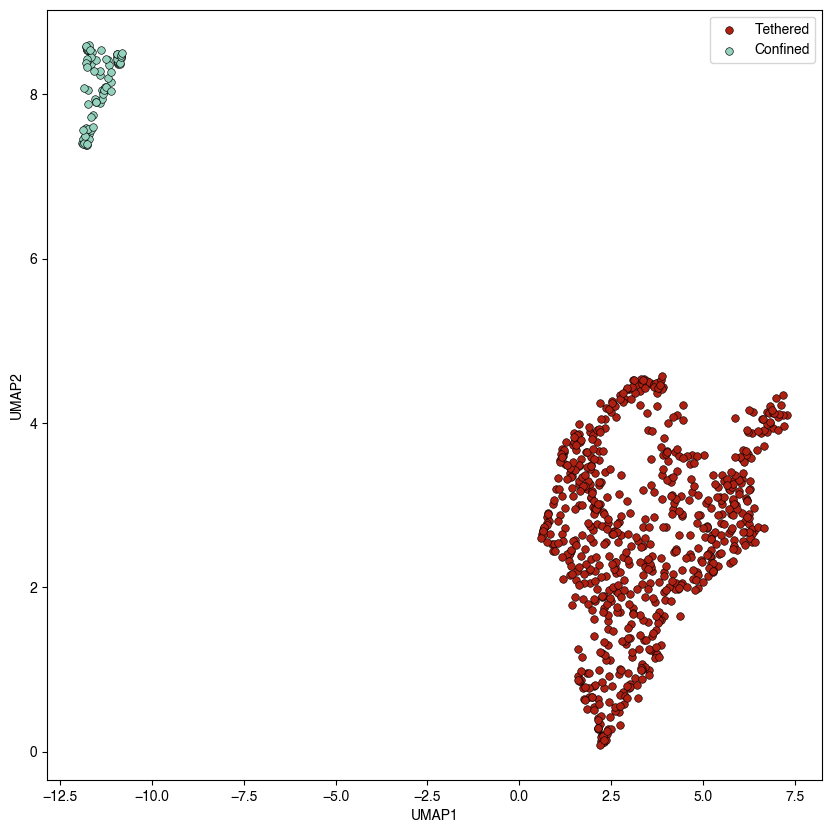

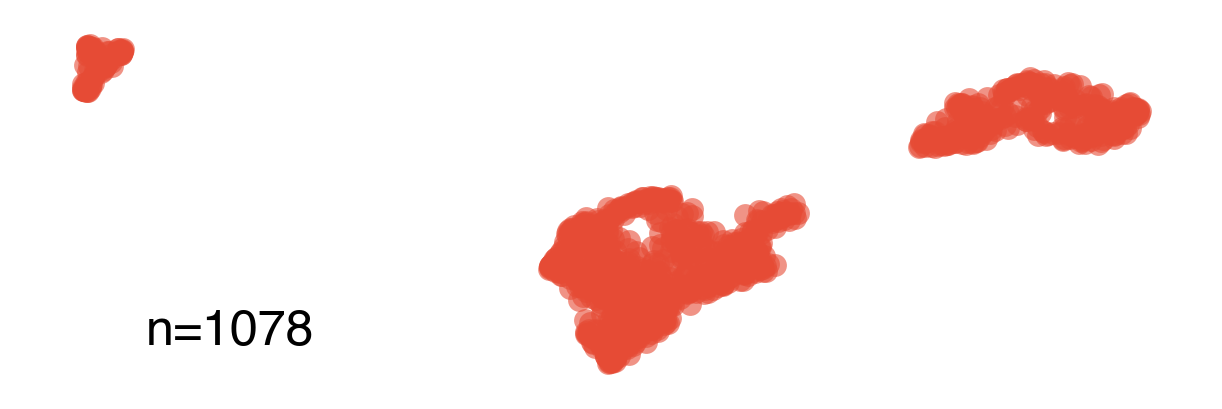

In [52]:
# 1. Calculate UMAP reduction
print("Calculating UMAP using metasim tools...")
if 'metasim' not in locals():
    import metasim
if 'plt' not in locals():
    import matplotlib.pyplot as plt
if 'np' not in locals():
    import numpy as np
# Import necessary style/colors if we want to match exactly, or standard matplotlib
try:
    from sciplotlib import style as spstyle
    style_context = spstyle.get_style('nature-reviews')
except ImportError:
    style_context = 'default' 

import umap
# Use fixed random_state=42 to match website analysis shape
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
umap_coord = reducer.fit_transform(embeddings)

# 2. Plot UMAP
print("Generating Plot...")

# Determine label order
label_order = sorted(list(set(all_labels)))
n_labels = len(label_order)

# Setup figure
with plt.style.context(style_context):
    fig, axes = plt.subplots(ncols=n_labels, nrows=1, figsize=(5 * n_labels, 5))
    if n_labels == 1: axes = [axes] # Handle single case

    ax_min = np.min(umap_coord)
    ax_max = np.max(umap_coord)
    
    for i, l in enumerate(label_order):
        idx = (labels == l)
        z = umap_coord[idx, ...]
        ax = axes[i]
        
        # Scatter plot
        ax.scatter(z[:, 0], z[:, 1], s=30, alpha=0.6, linewidths=0)
        
        # ax.set_xlim([ax_min, ax_max])
        # ax.set_ylim([ax_min, ax_max])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        # Remove spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        # Add N count
        text_x = ax.get_xlim()[0] + 0.1 * (ax.get_xlim()[1] - ax.get_xlim()[0]) 
        text_y = ax.get_ylim()[0] + 0.1 * (ax.get_ylim()[1] - ax.get_ylim()[0])
        ax.text(x=text_x, y=text_y, s=f'n={z.shape[0]}', fontdict={'size': 12})

    # plt.savefig("metasim_umap_viz.png", dpi=300, bbox_inches='tight')
    plt.show()

In [53]:
# Plot using metasim's built-in function (for comparison)
reducer = metasim.fret.tools.viz.get_umap_reducer(embeddings, n_neighbors=15)
umap_coord = reducer.transform(embeddings)

from sklearn.manifold import trustworthiness
# Calculate trustworthiness score (range 0-1)
# Higher is better (closer to 1.0 means local neighbors are preserved)
# Note: This can be slow for very large datasets (>10k points), but is fine for your ~4400 points.
score = trustworthiness(embeddings, umap_coord, n_neighbors=15)
print(f"Trustworthiness Score: {score:.4f}")

Trustworthiness Score: 0.9590


Generating Plot...


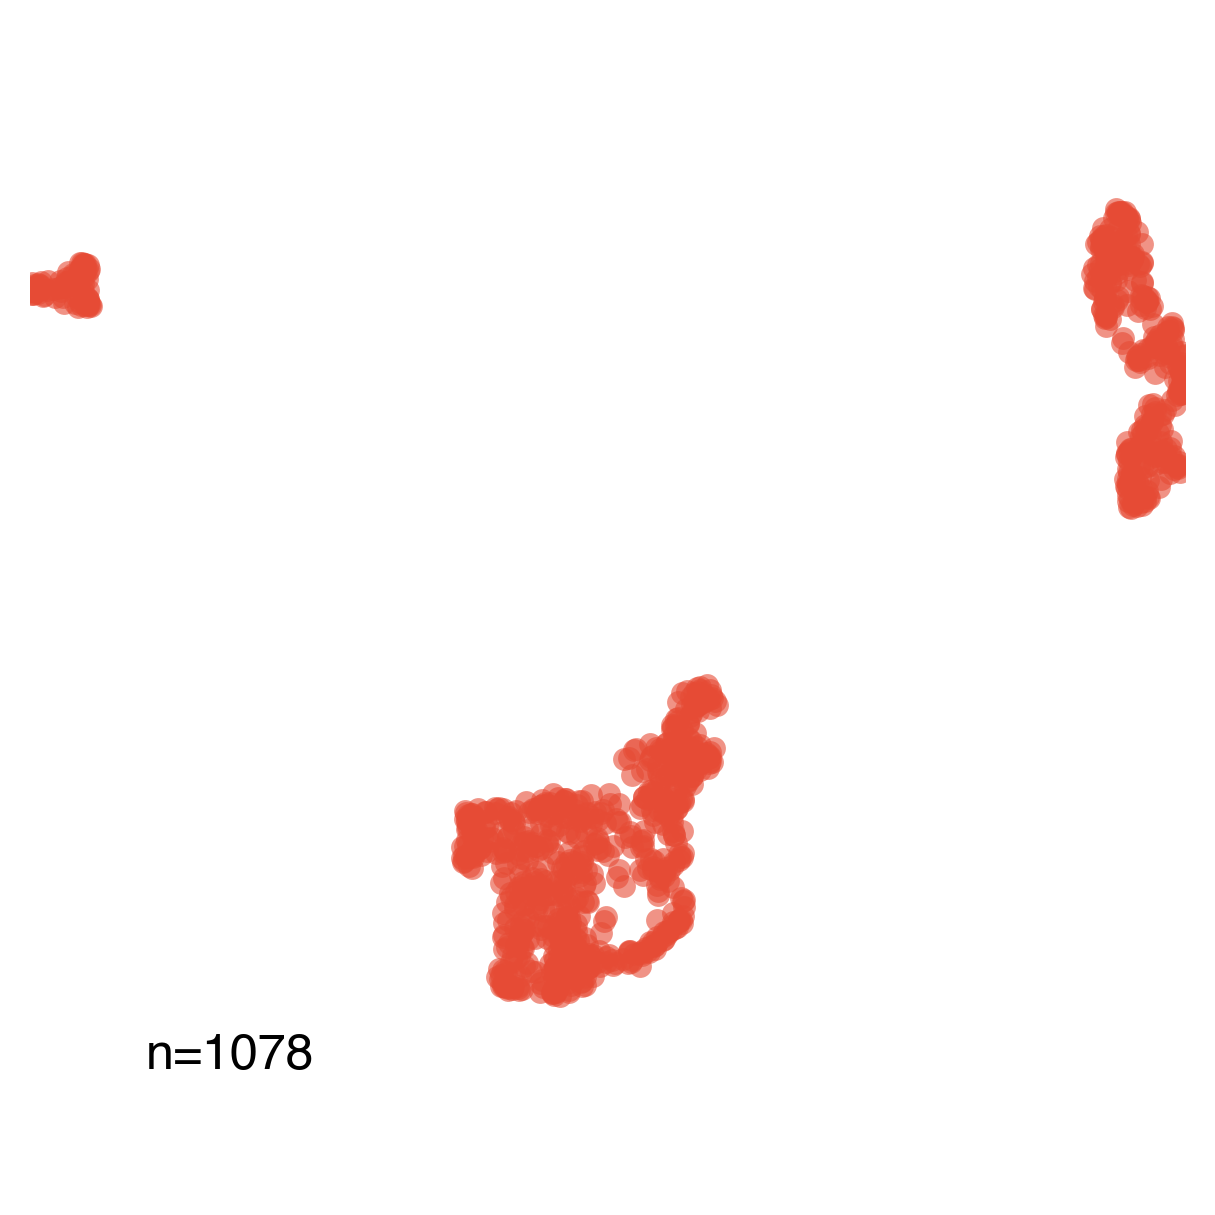

In [54]:
# 2. Plot UMAP (Custom Implementation to bypass library bug)
print("Generating Plot...")

# Determine label order
label_order = sorted(list(set(all_labels)))
n_labels = len(label_order)

# Setup figure
with plt.style.context(style_context):
    fig, axes = plt.subplots(ncols=n_labels, nrows=1, figsize=(5 * n_labels, 5))
    if n_labels == 1: axes = [axes] # Handle single case

    ax_min = np.min(umap_coord)
    ax_max = np.max(umap_coord)
    
    # Dummy color for compatibility with original visual style (if we want points colored)
    # The original function colored points by a 'color' array. 
    # Since we don't have one, we can color by density or just uniform.
    # We will use uniform color since that was the implication of passing zeros.
    
    for i, l in enumerate(label_order):
        idx = (labels == l)
        z = umap_coord[idx, ...]
        ax = axes[i]
        
        # Scatter plot
        # Original: s=30, alpha=0.6, linewidths=0
        ax.scatter(z[:, 0], z[:, 1], s=30, alpha=0.6, linewidths=0)
        
        ax.set_xlim([ax_min, ax_max])
        ax.set_ylim([ax_min, ax_max])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        # Remove spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
        ax.spines['left'].set_visible(False)
        
        # Add N count
        text_x = ax.get_xlim()[0] + 0.1 * (ax.get_xlim()[1] - ax.get_xlim()[0]) # Relative positioning safer
        text_y = ax.get_ylim()[0] + 0.1 * (ax.get_ylim()[1] - ax.get_ylim()[0])
        ax.text(x=text_x, y=text_y, s=f'n={z.shape[0]}', fontdict={'size': 12})

    plt.show()

In [55]:

# # 2. Visualize with META-SiM (3D Interactive Dashboard)
import pandas as pd
# import plotly.graph_objects as go
# import umap
# import numpy as np
# from ipywidgets import VBox, Label
# import plotly.express as px

# print("Calculating 3D UMAP...")

# try:
#     # 1. Calculate 3D UMAP reduction
#     reducer_3d = umap.UMAP(n_components=3, n_neighbors=30, n_epochs=500, min_dist=0.1, random_state=42)
#     umap_3d = reducer_3d.fit_transform(embeddings)

#     # 2. Prepare Data
#     df_plot = pd.DataFrame(umap_3d, columns=['UMAP1', 'UMAP2', 'UMAP3'])
    
#     if 'labels' in locals():
#         df_plot['Condition'] = labels
#     else:
#         df_plot['Condition'] = ['Unknown'] * len(umap_3d)
        
#     # Color mapping
#     unique_conditions = df_plot['Condition'].unique()
#     colors = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA', '#FFA15A', '#19D3F3', '#FF6692', '#B6E880', '#FF97FF', '#FECB52']
#     color_map = {cond: colors[i % len(colors)] for i, cond in enumerate(unique_conditions)}
    
#     # 3. Create FigureWidget for 3D Scatter
#     f_scatter = go.FigureWidget()
    
#     for cond in unique_conditions:
#         mask = df_plot['Condition'] == cond
#         f_scatter.add_trace(go.Scatter3d(
#             x=df_plot.loc[mask, 'UMAP1'],
#             y=df_plot.loc[mask, 'UMAP2'],
#             z=df_plot.loc[mask, 'UMAP3'],
#             mode='markers',
#             marker=dict(size=3, color=color_map[cond]),
#             name=cond,
#             # Store absolute indices
#             customdata=np.where(mask)[0] 
#         ))

#     f_scatter.update_layout(
#         title="3D UMAP (Hover to view trace)",
#         scene=dict(
#             xaxis_title='UMAP 1',
#             yaxis_title='UMAP 2',
#             zaxis_title='UMAP 3'
#         ),
#         margin=dict(l=0, r=0, b=0, t=30),
#         legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.05)
#     )

#     # 4. Create FigureWidget for Time Trace
#     f_trace = go.FigureWidget()
#     # Add empty trace
#     f_trace.add_trace(go.Scatter(y=[], mode='lines', name='Trace'))
    
#     # Update layout - ensure autoscale by NOT setting range
#     f_trace.update_layout(
#         title="Time Trace", 
#         xaxis_title="Time", 
#         yaxis_title="Intensity",
#         yaxis=dict(autorange=True) # Explicitly ask for autorange
#     )

#     # 5. Define Hover Callback
#     def update_trace(trace, points, selector):
#         if not points.point_inds:
#             return
            
#         ind = points.point_inds[0]
#         global_ind = trace.customdata[ind]
        
#         if 'traces_valid' in globals() and global_ind < len(traces_valid):
#             t_data = traces_valid[global_ind]
            
#             with f_trace.batch_update():
#                 f_trace.data[0].y = t_data
#                 f_trace.layout.title.text = f"Trace for Index {global_ind} ({df_plot.iloc[global_ind]['Condition']})"
#                 # Don't manually set y-range, let it float
#         else:
#             print(f"No trace data found for index {global_ind}")

#     for scatter_trace in f_scatter.data:
#         scatter_trace.on_hover(update_trace)

#     # 6. Display Dashboard
#     dashboard = VBox([f_scatter, f_trace])
#     display(dashboard)
#     print("Dashboard loaded. Hover over points to see traces.")

# except Exception as e:
#     print(f"Error in visualization: {e}")
#     # Fallback
#     fig = px.scatter_3d(df_plot, x='UMAP1', y='UMAP2', z='UMAP3', color='Condition', title="3D UMAP (Static Fallback)")
#     fig.show()

In [56]:
# Get the number of clusters based on the 3D UMAP results (select visually)
n_clusters = 3
print(f"Number of clusters (conditions) detected: {n_clusters}")

Number of clusters (conditions) detected: 3


Select a random representative trace from each of the clusters and plot it

In [57]:

# Clustering and Representative Traces (2D Projection, K=3)
print("Performing clustering to find representative traces...")

# 1. Calculate 2D UMAP for final cluster figure
print("Calculating 2D UMAP for final cluster figure...")
# Ensure we use n_components=2 explicitly
if 'umap' not in locals():
    import umap

reducer_2d = umap.UMAP(n_components=2, n_neighbors=15, n_epochs=500, min_dist=0.1, random_state=42)
umap_2d = reducer_2d.fit_transform(embeddings)

# 2. Perform Clustering (K-Means on 2D UMAP coords)
# User observed 3 clusters
from sklearn.cluster import KMeans
n_clusters = 3  # Explicitly defined
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
cluster_labels_km = kmeans.fit_predict(umap_2d)

# # 3. Select ONE RANDOM representative trace from EACH cluster
# # Strategy: Find all points in cluster, pick one index randomly
# print(f"Selecting a random representative trace for each of the {n_clusters} clusters...")

# fig, axes = plt.subplots(n_clusters, 1, figsize=(10, 3*n_clusters), sharex=True)
# if n_clusters == 1: axes = [axes]

# for i in range(n_clusters):
#     cluster_indices = np.where(cluster_labels_km == i)[0]
    
#     if len(cluster_indices) > 0:
#         # Pick random index
#         rand_idx_local = np.random.choice(len(cluster_indices))
#         rand_idx_global = cluster_indices[rand_idx_local]
        
#         if 'traces_valid' in locals() and rand_idx_global < len(traces_valid):
#             t_data = traces_valid[rand_idx_global]
#             t_label = labels[rand_idx_global] if 'labels' in locals() else f"Trace {rand_idx_global}"
            
#             ax = axes[i]
#             ax.plot(t_data, color='blue', linewidth=1)
#             ax.set_title(f"Cluster {i+1} Random Rep. (Index {rand_idx_global}, {t_label})")
#             ax.grid(True, alpha=0.3)
            
#             if i == n_clusters - 1:
#                 ax.set_xlabel("Time")
#             ax.set_ylabel("Intensity")
#     else:
#         print(f"Cluster {i+1} has no points!")

# plt.tight_layout()
# plt.show()

# # 4. Visualize Clusters on 2D UMAP
# df_2d = pd.DataFrame(umap_2d, columns=['UMAP1', 'UMAP2'])
# df_2d['Cluster'] = cluster_labels_km.astype(str)
# if 'labels' in locals():
#     df_2d['Condition'] = labels

# # Plot 2D scatter
# import plotly.express as px
# fig = px.scatter(
#     df_2d, x='UMAP1', y='UMAP2', 
#     color='Cluster',
#     title="2D UMAP Colored by K-Means Clusters (k=3)",
#     opacity=0.8,
#     hover_data=['Condition'] if 'labels' in locals() else None
# )

# # Change the limits to be the same for x and y for better visual comparison
# ax_min = np.min(umap_2d)
# ax_max = np.max(umap_2d)
# fig.update_layout(
#     xaxis=dict(range=[ax_min, ax_max]),
#     yaxis=dict(range=[ax_min, ax_max]),
#     xaxis_title='UMAP 1',
#     yaxis_title='UMAP 2',
#     title="2D UMAP Colored by K-Means Clusters (k=3)"
# )
# fig.update_traces(marker=dict(size=5))
# fig.show()

Performing clustering to find representative traces...
Calculating 2D UMAP for final cluster figure...


/Users/samm/miniforge3/envs/ctrap/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [58]:
# 3. Calculate the average distance trace for each cluster
# Use to store average distances for each representative trace
temp_average_distance_lst = []
unique_cluster_labels = np.unique(cluster_labels_km)
print(unique_cluster_labels)

for i, cluster_str in enumerate(unique_cluster_labels):
    cluster_id = int(cluster_str)
    cluster_indices = np.where(cluster_labels_km == cluster_id)[0]
    cluster_traces = [traces_valid[idx] for idx in cluster_indices if idx < len(traces_valid)]
    
    if len(cluster_indices) == 0:
        continue

    lengths = [len(t) for t in cluster_traces]
    if len(set(lengths)) > 1:
        min_len = min(lengths)
        cluster_traces_arr = np.array([t[:min_len] for t in cluster_traces])
    else:
        cluster_traces_arr = np.array(cluster_traces)
    
    try:
        mean_trace = np.mean(cluster_traces_arr, axis=0)
        # average distance (float)
        mean_trace_distance = np.mean(mean_trace)
        temp_average_distance_lst.append([cluster_id, mean_trace_distance])
    except Exception as e:
        print(f"Error computing mean trace for cluster {i}: {e}")
        continue
average_distance_lst = sorted(temp_average_distance_lst, key=lambda x: x[1], reverse=True)
average_distance_lst

[0 1 2]


[[1, np.float64(0.13852894922281045)],
 [0, np.float64(-0.06498315290618248)],
 [2, np.float64(-0.16661773405047492)]]

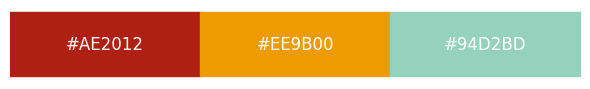

In [59]:
from color_palette import *
color_palette = get_color_palette(n=3)
# Plot the color palette to verify
fig, ax = plt.subplots(figsize=(6, 1))
for i, color in enumerate(color_palette):
    ax.fill_between([i, i+1], 0, 1, color=color)
    ax.text(i + 0.5, 0.5, f"{color}", va='center', ha='center', color='white', fontsize=12)
ax.set_xlim(0, len(color_palette))
ax.set_yticks([])
ax.set_xticks([])
# remove spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.spines['left'].set_visible(False)
plt.tight_layout()
plt.show()

In [60]:
cluster_plot_df = pd.DataFrame(columns=['Cluster Index', 'Cluster Label', 'Cluster Rank', 'Color'])
cluster_plot_df['Cluster Index'] = unique_cluster_labels

plot_labels_colors_dict = {
    "Tethered": color_palette[0],
    "Boundary": color_palette[1],
    "Confined": color_palette[2]
}

cluster_labels_dict = {
    1: "Tethered",
    2: "Boundary",
    3: "Confined"
}

# Assign ranks based on average distance
for rank, idx in enumerate(average_distance_lst):
    print(f"Cluster {idx[0]}: Average Distance = {idx[1]:.4f}, Rank = {rank+1}, Label = {cluster_labels_dict.get(rank+1, 'Unknown')}")
    cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == idx[0], 'Cluster Rank'] = rank + 1
    cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == idx[0], 'Color'] = plot_labels_colors_dict[list(plot_labels_colors_dict.keys())[rank]]
    cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == idx[0], 'Cluster Label'] = cluster_labels_dict.get(rank+1, 'Unknown')

cluster_plot_df.sort_values('Cluster Rank', inplace=True)

cluster_plot_df

Cluster 1: Average Distance = 0.1385, Rank = 1, Label = Tethered
Cluster 0: Average Distance = -0.0650, Rank = 2, Label = Boundary
Cluster 2: Average Distance = -0.1666, Rank = 3, Label = Confined


,Cluster Index,Cluster Label,Cluster Rank,Color
1,1,Tethered,1,#AE2012
0,0,Boundary,2,#EE9B00
2,2,Confined,3,#94D2BD


In [62]:
# 4. Visualize Clusters on 2D UMAP
df_2d = pd.DataFrame(umap_2d, columns=['UMAP1', 'UMAP2'])
df_2d['Cluster'] = cluster_labels_km.astype(str)

if 'labels' in locals():
    df_2d['Condition'] = labels
    
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 10))

for cluster_id in unique_cluster_labels:
    cluster_mask = df_2d['Cluster'] == str(cluster_id)
    cluster_size = np.sum(cluster_mask)
    
    sns.scatterplot(data=df_2d[cluster_mask],
                    x='UMAP1',
                    y='UMAP2',
                    color=cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == cluster_id, 'Color'].values[0],
                    label=cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == cluster_id, 'Cluster Label'].values[0],
                    ax=ax,
                    s=30,
                    edgecolor='black'
                    )

x = umap_2d[:, 0]
y = umap_2d[:, 1]

# Normalize the axis for better visualization
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()

# Calculate the length
x_length = x_max - x_min
y_length = y_max - y_min

# Determine the maximum length
max_length = max(x_length, y_length)

# Center the plot
x_center = (x_max + x_min) / 2
y_center = (y_max + y_min) / 2

# Set limits to make the plot square
x_min = x_center - max_length / 2
x_max = x_center + max_length / 2
y_min = y_center - max_length / 2
y_max = y_center + max_length / 2

ax.set_xlim(x_min - 0.05 * abs(x_max - x_min), x_max + 0.05 * abs(x_max - x_min))
ax.set_ylim(y_min - 0.05 * abs(y_max - y_min), y_max + 0.05 * abs(y_max - y_min))

# Remove x and y axis labels and ticks
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel('')
ax.set_ylabel('')

# Remove the frame
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)

try:
    ax.legend(loc='upper left', frameon=False, fontsize=32)
except:
    pass

plt.tight_layout()

file_list_base = [f.replace('.json.zip', '') for f in file_list]
save_name = f"./results/UMAP/2D_UMAP_Clusters_{'_'.join(file_list_base)}.svg"
os.makedirs(os.path.dirname(save_name), exist_ok=True)
plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
# Plot random representative traces
# fig, axes = plt.subplots(n_clusters, 1, figsize=(6, 2*n_clusters), sharex=True)
# if n_clusters == 1: axes = [axes]
# for cluster_id in unique_cluster_labels:
#     cluster_indices = np.where(cluster_labels_km == cluster_id)[0]
    
#     if len(cluster_indices) > 0:
#         # Pick random index
#         rand_idx_local = np.random.choice(len(cluster_indices))
#         rand_idx_global = cluster_indices[rand_idx_local]

#         if rand_idx_global < len(traces_valid):
#             t_data = traces_valid[rand_idx_global]
#             t_label = labels[rand_idx_global]
#             time_trace = np.arange(len(t_data))  # Assuming uniform time intervals
#             time_trace_seconds = time_trace * 0.05  # Assuming 0.1s intervals
            
#             ax = axes[cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == cluster_id, 'Cluster Rank'].values[0] - 1]
#             ax.plot(time_trace_seconds,
#                     t_data,
#                     color=cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == cluster_id, 'Color'].values[0],
#                     alpha=0.8,
#                     linewidth=2.5
#                     )
#             ax.set_ylabel("distance (μm)")
#             ax.set_xlabel("Time (s)")
            
#             ax.axhline(0, color='grey', linestyle='--', linewidth=1.5, zorder=-1)

# # Remove the top and right spines
# # Make the y-axis limits and ticks consistent (every 0.1 units)
# for ax in axes:
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     # ax.set_ylim(bottom=min(0, ax.get_ylim()[0]))  # Ensure y-axis starts at 0 or below
#     ax.set_yticks(np.arange(np.round(ax.get_ylim()[0], 1), ax.get_ylim()[1] + 0.2, 0.2))

# plt.tight_layout()
# save_name = f"./results/traces/Cluster_Traces_{'_'.join(file_list_base)}.svg"
# os.makedirs(os.path.dirname(save_name), exist_ok=True)
# plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
# plt.show()

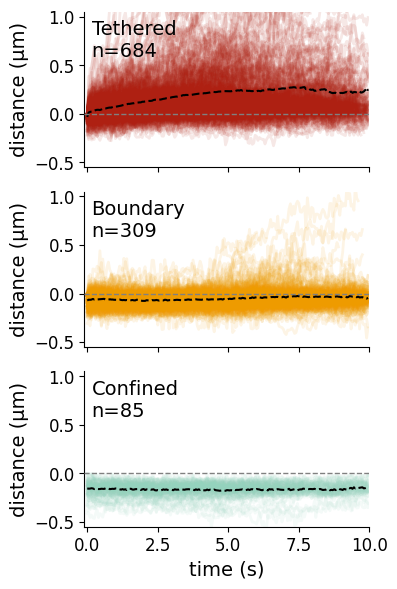

In [ ]:
unique_clusters = np.sort(df_2d['Cluster'].unique())

def mean_trace_numpy(traces):
    # 1. Find the length of the longest trace
    max_len = max(len(t) for t in traces)
    
    # 2. Create a matrix full of NaNs
    # Shape: (number of traces, max length)
    arr = np.full((len(traces), max_len), np.nan)
    
    # 3. Fill the matrix with your data
    for i, trace in enumerate(traces):
        arr[i, :len(trace)] = trace
        
    # 4. Calculate the mean of each column, ignoring NaNs
    # axis=0 means "down the columns"
    return np.nanmean(arr, axis=0)

# Plot all the traces in each cluster
fig, axes = plt.subplots(n_clusters, 1, figsize=(4, 2*n_clusters), sharex=True)

if n_clusters == 1: axes = [axes]

for i, cluster_str in enumerate(unique_cluster_labels):
    cluster_id = int(cluster_str)
    
    # 1. Get indices and traces for this cluster
    # cluster_labels_km is aligned with embeddings/traces_valid
    cluster_indices = np.where(cluster_labels_km == cluster_id)[0]
    cluster_traces = [traces_valid[idx] for idx in cluster_indices if idx < len(traces_valid)]
    
    if len(cluster_traces) == 0:
        continue
        
    # 2. Setup Subplot
    ax = axes[cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == cluster_id, 'Cluster Rank'].values[0] - 1]
    
    # Get color
    color = cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == cluster_id, 'Color'].values[0] 
    label = cluster_plot_df.loc[cluster_plot_df['Cluster Index'] == cluster_id, 'Cluster Label'].values[0]
    
    max_plot = 500
    indices_to_plot = np.random.choice(len(cluster_indices), size=min(len(cluster_indices), max_plot), replace=False)
    
    for idx_trace in indices_to_plot:
        t_data = cluster_traces[idx_trace]
        time_trace = np.arange(len(t_data))  # Assuming uniform time intervals
        time_trace_seconds = time_trace * 0.05  # Assuming 0.1
        ax.plot(time_trace_seconds,
                t_data,
                color=color,
                alpha=0.10,
                linewidth=2
                )
    
    # Plot the mean trace
    try:
        # Take the average at each time point across all traces in the cluster
        # The traces are heterogenous in length, so we need to average at each time point
        time_trace = np.arange(max(len(trace) for trace in cluster_traces))  # Assuming uniform time intervals
        time_trace_seconds = time_trace * 0.05  # Assuming 0.1
        mean_trace = mean_trace_numpy(cluster_traces)
        ax.plot(time_trace_seconds,
                mean_trace,
                color='black',
                alpha=1.0,
                linewidth=1.5,
                linestyle='--'
                )

    except Exception as e:
        print(f"Error computing mean trace for cluster {cluster_id}: {e}")
        
    try:
        # Add text label for the cluster
        ax.text(0.025, 0.95, f"{label}\nn={len(cluster_traces)}", transform=ax.transAxes, ha='left', va='top', fontsize=14, color="black")
        
    except Exception as e:
        print(f"Error adding text label for cluster {cluster_id}: {e}")
    
# Remove the top and right spines
# Make the y-axis limits and ticks consistent (every 0.1 units)
for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.set_ylim(bottom=min(0, ax.get_ylim()[0]))  # Ensure y-axis starts at 0 or below
    ax.axhline(0, color='grey', linestyle='--', linewidth=1, zorder=11)
    # Plot the average line
    ax.set_ylim(-0.55, 1.05)
    ax.set_xlim(-0.1, 10)
    ax.set_ylim(bottom=min(0, ax.get_ylim()[0]))  # Ensure y-axis starts at 0 or below
    ax.set_ylabel("distance (μm)", fontsize=14)
    ax.tick_params(axis='both', labelsize=12)

ax = axes[-1]
ax.set_xlabel("time (s)", fontsize=14)
    
plt.tight_layout()

save_name = f"./results/traces/Combined_{'_'.join(file_list_base)}.svg"
os.makedirs(os.path.dirname(save_name), exist_ok=True)
plt.savefig(save_name, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

In [ ]:
# Save the clustering results as a CSV
result_df = cluster_plot_df.copy()
# Save number of traces in each cluster
result_df['Num Traces'] = result_df['Cluster Index'].apply(lambda x: np.sum(cluster_labels_km == x))
# Save the trace indices in each cluster (based on the original indices)
result_df['Trace Indices'] = result_df['Cluster Index'].apply(lambda x: np.where(cluster_labels_km == x)[0].tolist())

save_name = f"./results/clustering_results/result_{'_'.join(file_list_base)}.csv"
os.makedirs(os.path.dirname(save_name), exist_ok=True)
result_df.to_csv(save_name, index=False)